In [1]:
# Стандартные библиотеки Python
import json
import os
import time

from datetime import datetime
from typing import List, Dict, Any

# Внешние библиотеки
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import clear_output

# Локальные модули
from board import Board
from game import Game, NumpyEncoder
from mcts_agent import MCTS_Agent, MCTSNode
from model_manager import ModelManager, create_new_model
from random_network import RandomNetwork, PytorchAgentWrapper
from rl_agent import RLAgent
from noise import DirichletNoiseConfig
from train_network import train_network_steps, train_network_epochs
from self_play import generate_self_play_games

In [2]:
SAVE_DIR = "test1\\models\\"
os.makedirs(SAVE_DIR, exist_ok=True)

DATA_SAVE_DIR = ".\\test1\\games\\" 
RANDOM_SAVE_DIR = ".\\test1\\random\\" 

os.makedirs(DATA_SAVE_DIR, exist_ok=True)
os.makedirs(RANDOM_SAVE_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Гиперпараметры
NUM_GAMES_TO_GENERATE = 2
MAX_MOVES_PER_GAME = 100
GAMES_BATCH = 1
TRAINING_STEPS = 56
BATCH_SIZE = 256
LEARNING_RATE = 0.001

In [3]:
def create_agent_name() -> str:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"agent_{timestamp}.pth"
    return filename

import glob
def get_most_recent_filename(path: str) -> str:
    
    search_pattern = os.path.join(path, "agent_*.pth")
    filepaths = glob.glob(search_pattern)

    filepaths.sort(key=lambda x: -os.path.getmtime(x))
    if len(filepaths) > 0:
        return filepaths[0].split('\\')[-1]
    return None
get_most_recent_filename(SAVE_DIR)

'agent_20260410_214118.pth'

In [4]:

model_manager = ModelManager(
    RLAgent, 
    save_dir=SAVE_DIR, 
    device=DEVICE
)


In [5]:


def get_or_create_recent_model():
    current_best_model_id = get_most_recent_filename(SAVE_DIR)
    if current_best_model_id == None:
        create_new_model(model_manager, create_agent_name())
        current_best_model_id = get_most_recent_filename(SAVE_DIR)
    best_model = model_manager.load_model_weights(current_best_model_id)
    return best_model

def create_random_games(path: str):
    best_model = get_or_create_recent_model()
    
    network = RandomNetwork()
    
    agent_rl = MCTS_Agent(temperature=1.0)
    agent_rl.set_network(network)
        
    generate_self_play_games(games_to_generate = 5000, games_batch = 100,
        rl_agent = agent_rl, max_moves = 50,
        file_path = path)

def initial_train():

    all_training_data = load_and_combine_data_by_count(DATA_SAVE_DIR, 100000)
    
    challenger_model = get_or_create_recent_model()
    optimizer = torch.optim.Adam(challenger_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) 
    train_network_epochs(model=challenger_model, optimizer=optimizer, training_data=all_training_data, epochs=2, batch_size=256, device=DEVICE)
    
    challenger_id = create_agent_name()
    challenger_metadata = {'parent_version': 0}
    model_manager.save_checkpoint(challenger_model, optimizer, challenger_metadata, f"{challenger_id}")
    print(f"Новая модель-претендент '{challenger_id}' обучена и сохранена.")

In [8]:
import h5py
def create_random_dataset(int n_thread) -> str:
    file_name = f"dataset_{n_thread}.h5"
    full_path = os.path.join(RANDOM_SAVE_DIR, file_name)
    with h5py.File(full_path, 'w') as f:
        # Здесь можно сразу создать группы или датасеты
        f.create_group('games')
        
        print(f"HDF5 файл успешно создан по пути: {full_path}")
    return full_path


HDF5 файл успешно создан по пути: .\test1\random\dataset.h5


In [ ]:
def create_random_games(path):
    
    network = RandomNetwork()
    
    agent_rl = MCTS_Agent(temperature=1.0)
    agent_rl.set_network(network)
        
    generate_self_play_games(games_to_generate = 500, games_batch = 100,
        rl_agent = agent_rl, max_moves = 50,
        file_path = path)

In [9]:
import h5py
def create_random_dataset(int n_thread) -> str:
    file_name = f"dataset_{n_thread}.h5"
    full_path = os.path.join(RANDOM_SAVE_DIR, file_name)
    with h5py.File(full_path, 'w') as f:
        # Здесь можно сразу создать группы или датасеты
        f.create_group('games')
        
        print(f"HDF5 файл успешно создан по пути: {full_path}")
    return full_path

def create_random_games(path):
    
    network = RandomNetwork()
    
    agent_rl = MCTS_Agent(temperature=1.0)
    agent_rl.set_network(network)
        
    generate_self_play_games(games_to_generate = 500, games_batch = 100,
        rl_agent = agent_rl, max_moves = 50,
        file_path = path)
    
for i in range(10):
    path = create_random_dataset(i)
    create_random_games(path)
    


ИГРА 4/5000 | ПРОШЛО 3.443260908126831c.
ХОД 1
Текущий игрок: ⚫ ЧЕРНЫЕ

 0|🟩🟩🟩🟩🟩🟩🟩
 1|🟩🟩🟩🟩🟩🟩🟩
 2|🟩🟩🟩🟩🟩🟩🟩
 3|🟩🟩🟩🟩🟩🟩🟩
 4|🟩🟩🟩🟩🟩🟩🟩
 5|🟩🟩🟩🟩🟩🟩🟩
 6|🟩🟩🟩🟩🟩🟩🟩


KeyboardInterrupt: 

In [ ]:
for i in range(1):
    current_best_model_id = get_most_recent_filename(SAVE_DIR)
    
    best_model = model_manager.load_model_weights(current_best_model_id)     

    network = PytorchAgentWrapper(best_model, device=DEVICE)
    agent_rl = MCTS_Agent(network, temperature=1.0)
    
    generate_self_play_games(games_to_generate=NUM_GAMES_TO_GENERATE, games_batch=GAMES_BATCH, rl_agent = agent_rl, max_moves=MAX_MOVES_PER_GAME,
                            file_path=full_path)


ИГРА 1/2 | ПРОШЛО 0.0c.
ХОД 71
Текущий игрок: ⚫ ЧЕРНЫЕ

 0|🟩⚫🟩⚫⚫🟩🟩
 1|🟩🟩🔴🟩⚫🟩🟩
 2|🟩🟩⚫🟩🔴🟩🟩
 3|🟩🟩🟩🟩⚫🟩🟩
 4|🟩⚫🟩🟩🟩🟩🟩
 5|🟩⚫🟩🟩🟩⚫🟩
 6|🟩🟩🟩⚫⚫⚫🟩


In [27]:
import time

big = 4000000000
int(big - time.time())

2223850465

In [ ]:
DATA_SAVE_DIR = ".\\test\\" 
all_training_data = load_and_combine_data_by_count(DATA_SAVE_DIR, 100000)

In [ ]:
games = [i for i in all_training_data if i['turn'] == 0]
games = games[::-1]

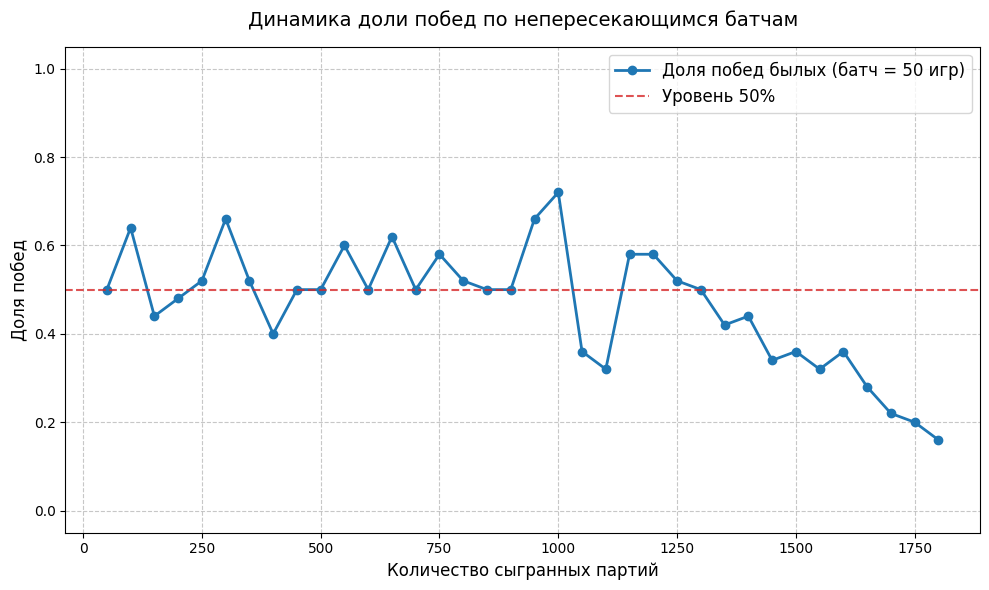

In [42]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Создаем DataFrame и сразу переводим исходы в бинарный формат (1 = победа, 0 = поражение)
df = pd.DataFrame(games)
df['is_win'] = (df['value'] == -1).astype(int)

# Разбиваем индексы на блоки по 50 (// 50) и считаем среднее для каждой группы
chunk_size = 50
winrates = df.groupby(df.index // chunk_size)['is_win'].mean()

# Для оси X высчитываем количество сыгранных игр к концу каждого батча (50, 100, 150...)
x_values = (winrates.index + 1) * chunk_size

plt.figure(figsize=(10, 6), dpi=100)

# Строим график по точкам
plt.plot(x_values, winrates, marker='o', linestyle='-', color='#1f77b4', 
         linewidth=2, markersize=6, label=f'Доля побед былых (батч = {chunk_size} игр)')

# Линия 50% для наглядности
plt.axhline(y=0.5, color='#d62728', linestyle='--', alpha=0.8, label='Уровень 50%')

plt.title('Динамика доли побед по непересекающимся батчам', fontsize=14, pad=15)
plt.xlabel('Количество сыгранных партий', fontsize=12)
plt.ylabel('Доля побед', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.tight_layout()

plt.show()


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_average_entropy_by_turn(dataset):
    """
    Функция принимает список словарей (датасет ходов) и строит график
    средней энтропии mcts_policy от номера хода для каждого из двух игроков.
    """
    # Словари для группировки значений энтропии по номеру хода
    # Ключ: номер хода (turn), Значение: список значений энтропии
    entropy_p1 = defaultdict(list)
    entropy_p2 = defaultdict(list)
    
    for move in dataset:
        turn = move['turn']
        policy = move['mcts_policy']
        state_tensor = move['state_tensor']
        
        # Оставляем только вероятности > 0, чтобы избежать log(0)
        valid_probs = policy[policy > 0]
        
        # Считаем энтропию в битах (np.log2). Если хотите в натах, используйте np.log
        if len(valid_probs) > 0:
            entropy = -np.sum(valid_probs * np.log2(valid_probs))
        else:
            entropy = 0.0
            
        # Определяем игрока по последнему слою стейт-тензора
        # Индекс -1 означает последний слой матрицы размерностью (33, 7, 7)
        last_layer = state_tensor[-1]
        
        # Для надежности проверяем среднее значение слоя, а не строгое равенство == 1.0, 
        # чтобы избежать возможных багов с float32
        if np.mean(last_layer) > 0.5:
            # Слой заполнен единичками
            entropy_p1[turn].append(entropy - 1 if entropy > 2 else entropy)
        else:
            # Слой заполнен нулями
            entropy_p2[turn].append(entropy - 1 if entropy > 2 else entropy)
            
    # Подготавливаем данные для графиков: усредняем энтропию для каждого хода
    turns_p1 = sorted(entropy_p1.keys())
    avg_entropy_p1 = [np.mean(entropy_p1[t]) for t in turns_p1]
    
    turns_p2 = sorted(entropy_p2.keys())
    avg_entropy_p2 = [np.mean(entropy_p2[t]) for t in turns_p2]
    
    # Отрисовка графика
    plt.figure(figsize=(10, 6))
    
    # Рисуем линию Игрока 1, если для него есть данные
    if turns_p1:
        plt.plot(turns_p1, avg_entropy_p1, label='Черные', 
                 color='blue', marker='o', markersize=4, linestyle='-', alpha=0.8)
        
    # Рисуем линию Игрока 2, если для него есть данные
    if turns_p2:
        plt.plot(turns_p2, avg_entropy_p2, label='Белые', 
                 color='orange', marker='s', markersize=4, linestyle='-', alpha=0.8)
        
    plt.title('Средняя энтропия mcts_policy в зависимости от номера хода')
    plt.xlabel('Номер хода')
    plt.ylabel('Средняя энтропия (биты)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Пример вызова:
# plot_average_entropy_by_turn(moves_dataset)

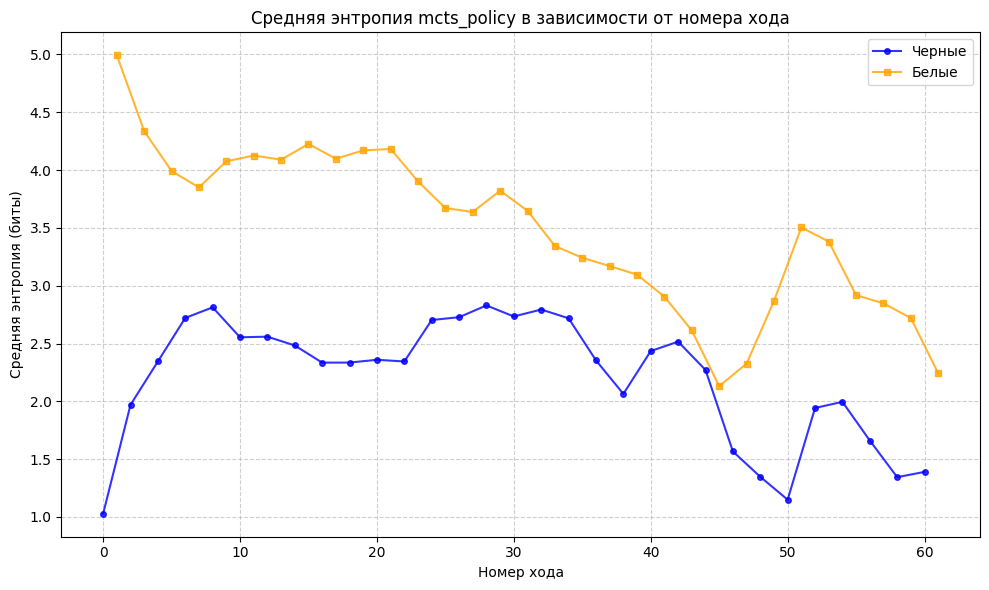

In [44]:
plot_average_entropy_by_turn(all_training_data[0:1000])

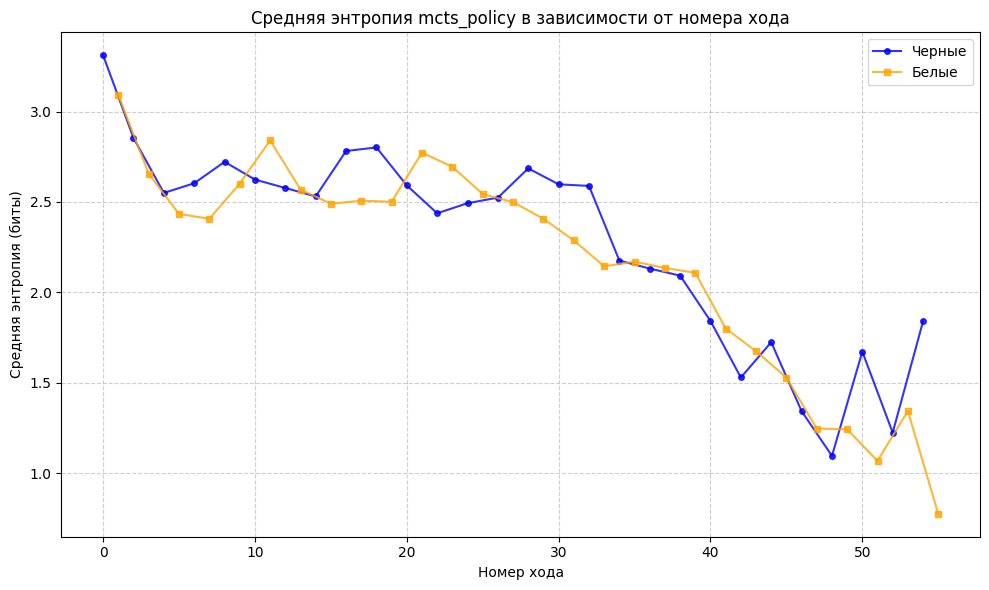

In [70]:
plot_average_entropy_by_turn(all_training_data[36000:37000])

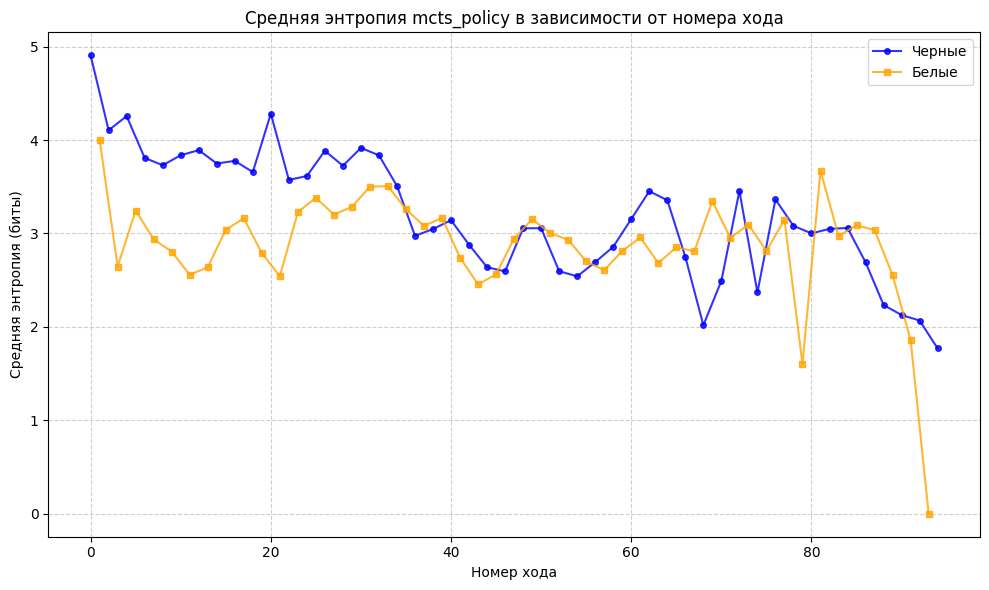

In [46]:
plot_average_entropy_by_turn(all_training_data[75000:76000])

In [65]:
from heatmaps import print_board_heatmaps_for_move
for i in range(6):
    print_board_heatmaps_for_move(
    move_index=i,
    history=0,
    states=all_training_data[0:1000],
    thresholds=(5, 10, 15, 25, 50, 95),  # легко крутить границы
)            
    #0:5 5:10 10:15 15:25 25:50 40:95  %  +
    #🟢 🟡    🟠   🟤    🔴   🟣     🔵
    
    clear_output(wait=True)
    time.sleep(1)

Ход (turn) == 5
Чёрные камни:
⚪⚪🟢🟢⚪🟢⚪
⚪⚪⚪🟢🟡🟢🟢
🟡🟡🟡🟠🟠🟡🟢
⚪🟢🟡🟡🟢🟢🟡
⚪🟡🟡🟤🟠🟢🟢
🟢⚪⚪⚪⚪⚪⚪
⚪🟡⚪⚪🟡⚪⚪

Белые камни:
⚪⚪⚪⚪⚪⚪⚪
⚪⚪⚪🟢⚪⚪⚪
⚪⚪🔴🟣🔴⚪⚪
⚪⚪🔴🟣🟣⚪⚪
⚪⚪🟡🔴🟤⚪🟢
⚪⚪⚪⚪🟢⚪⚪
⚪⚪🟢⚪⚪⚪⚪



In [ ]:

current_best_model_id = get_most_recent_filename(SAVE_DIR)
        
best_model = model_manager.load_model_weights(current_best_model_id)     
network = PytorchAgentWrapper(best_model, device=DEVICE)
agent_rl = MCTS_Agent(network, num_simulations=NUM_SIMULATIONS, temperature=1.0)
        
generate_self_play_games(games_to_generate=NUM_GAMES_TO_GENERATE, games_batch=GAMES_BATCH, rl_agent = agent_rl, max_moves=MAX_MOVES_PER_GAME,
                         data_save_dir=DATA_SAVE_DIR, random_moves=MAX_MOVES_PER_GAME + 1)

In [ ]:

MAX_MOVES_PER_GAME = 30

true_random = RandomNetwork()
true_random.randomise_value = True
true_random.randomise_score = False
true_random.value_modifier = 0.1

good = MCTS_Agent(network=true_random, num_simulations=2000, 
                  temperature=0, score_goal_mod = -10)
evil = MCTS_Agent(network=true_random, num_simulations=2, 
                  temperature=0, score_goal_mod = 0)

wins_challenger = 0
wins_best = 0

for i in range(TOURNAMENT_GAMES):
    print(f"\n--- Турнирная игра {i+1}/{TOURNAMENT_GAMES} ---")
    
    # Чередуем, кто играет черными, чтобы исключить преимущество первого хода
    if i % 2 == 0:
        game = play_tournament_game(good, evil, max_moves=MAX_MOVES_PER_GAME, 
                                    extra_text = f"ИГРА {i+1}/{TOURNAMENT_GAMES} | GOOD - ЧЕРНЫЕ | СЧЕТ - П{wins_challenger}/Ч{i - wins_challenger}")
        game.print_score()
        if game.get_winner() == game.board.BLACK:
            wins_challenger += 1
    else:
        game = play_tournament_game(evil, good, max_moves=MAX_MOVES_PER_GAME,
                                   extra_text = f"ИГРА {i+1}/{TOURNAMENT_GAMES} | GOOD - БЕЛЫЕ | СЧЕТ - П{wins_challenger}/Ч{i - wins_challenger}")
        game.print_score()
        if game.get_winner() == game.board.WHITE:
            wins_challenger += 1


    
    wins_best = TOURNAMENT_GAMES - wins_challenger
    
    print(f"Победитель партии: {game.get_winner()}. Текущий счет Претендента: {wins_challenger}/{i+1}")


print(f"\nРезультаты турнира: Претендент {wins_challenger} - {wins_best} Чемпион")

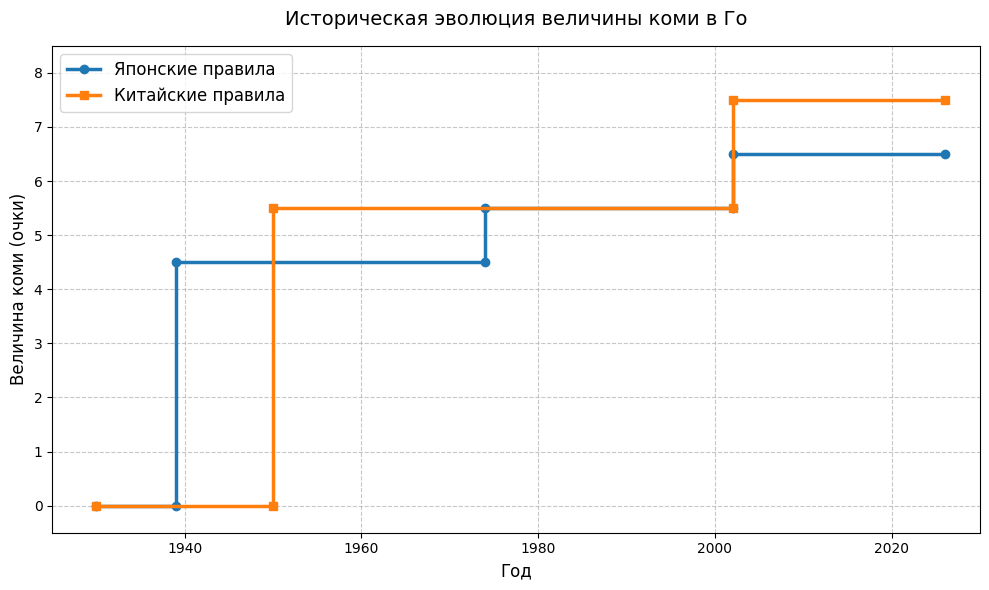

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

# Хронология изменения коми (дублирование годов создает вертикальные "скачки" на графике)
jap_years = [1930, 1939, 1939, 1974, 1974, 2002, 2002, 2026]
jap_komi = [0, 0, 4.5, 4.5, 5.5, 5.5, 6.5, 6.5]

chi_years = [1930, 1950, 1950, 2002, 2002, 2026]
chi_komi = [0, 0, 5.5, 5.5, 7.5, 7.5]

# Настройка размера и стиля графика для отчета
plt.figure(figsize=(10, 6), dpi=100)

# Построение линий
plt.plot(jap_years, jap_komi, marker='o', linestyle='-', linewidth=2.5, 
         markersize=6, label='Японские правила')
plt.plot(chi_years, chi_komi, marker='s', linestyle='-', linewidth=2.5, 
         markersize=6, label='Китайские правила')

# Оформление осей и заголовка академическом стиле
plt.title('Историческая эволюция величины коми в Го', fontsize=14, pad=15)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Величина коми (очки)', fontsize=12)

# Сетка и легенда
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')

# Настройка границ осей для наглядности
plt.xlim(1925, 2030)
plt.ylim(-0.5, 8.5)

# Компактное отображение
plt.tight_layout()

# Вывод графика в Jupyter
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_32048\1109340415.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', fontsize=12)


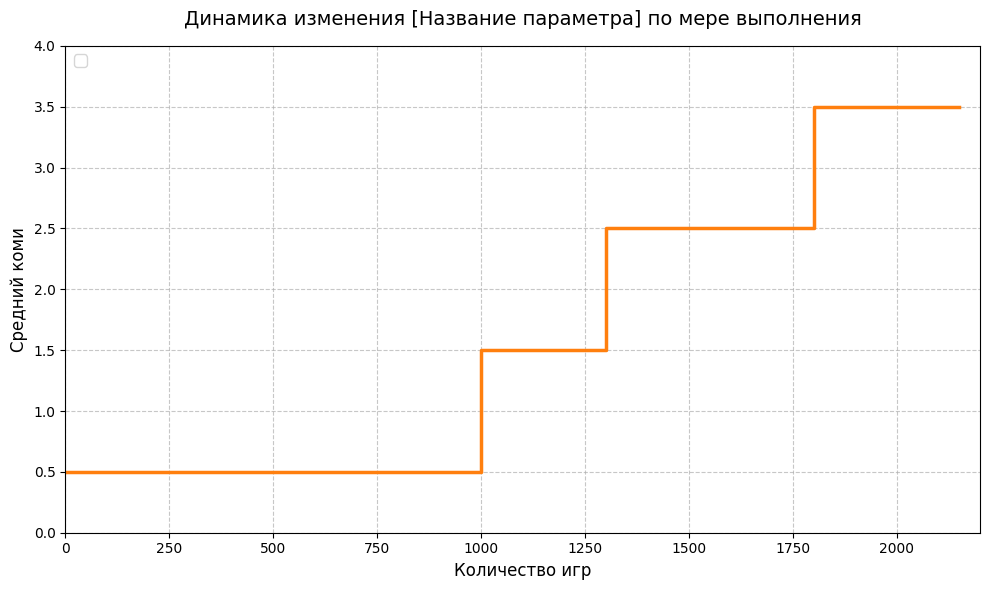

In [73]:

import matplotlib.pyplot as plt

# Координаты X (границы изменения) и Y (значения на интервалах)
# Последнее значение Y дублируется, чтобы линия дошла до x=2150 без скачка
x_steps = [0, 1000, 1300, 1800, 2150]
y_values = [0.5, 1.5, 2.5, 3.5, 3.5]

plt.figure(figsize=(10, 6), dpi=100)

# Построение ступенчатого графика (where='post' означает, что скачок происходит в конце интервала)
plt.step(x_steps, y_values, where='post', color='#ff7f0e', linewidth=2.5)

# Настройка оформления
plt.title('Динамика изменения [Название параметра] по мере выполнения', fontsize=14, pad=15)
plt.xlabel('Количество игр', fontsize=12)
plt.ylabel('Средний коми', fontsize=12)

# Сетка и оси
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize=12)

# Устанавливаем лимиты, чтобы график смотрелся аккуратно и ступеньки не прилипали к краям
plt.xlim(0, 2200)
plt.ylim(0, 4)

plt.tight_layout()

# Вывод графика в Jupyter
plt.show()


In [25]:
import numpy as np
import matplotlib.pyplot as plt

def generate_komi(mean_komi: float, max_komi: int = 15, std_dev: float = 3.0, flat_chance: float = 0.1) -> float:
    """
    Генерирует коми. С вероятностью flat_chance выбирает равномерно из всего диапазона,
    иначе использует нормальное распределение вокруг mean_komi.
    
    :param flat_chance: Шанс (0.0 - 1.0) выбрать плоское (uniform) распределение.
    """
    possible_values = np.arange(-max_komi + 0.5, max_komi, 1.0)
    
    # 1. Проверяем шанс на плоское распределение
    if np.random.random() < flat_chance:
        return np.random.choice(possible_values)
        
    # 2. Иначе используем стандартный колокол Гаусса
    probabilities = np.exp(-0.5 * ((possible_values - mean_komi) / std_dev) ** 2)
    probabilities /= np.sum(probabilities)
    
    return np.random.choice(possible_values, p=probabilities)



def test_komi_generation(mean_komi: float = 5.5, max_komi: int = 15, std_dev: float = 2.0, flat_chance: float = 0.1, num_samples: int = 20000):
    """Семплирует значения и рисует график."""
    samples = [generate_komi(mean_komi, max_komi, std_dev, flat_chance) for _ in range(num_samples)]
    unique_vals, counts = np.unique(samples, return_counts=True)
    
    plt.figure(figsize=(12, 6))
    plt.bar(unique_vals, counts / num_samples * 100, width=0.8, color='#4C72B0', edgecolor='black')
    
    plt.title(f'Komi Distribution (Mean: {mean_komi}, StdDev: {std_dev}, Flat Chance: {flat_chance})')
    plt.xlabel('Сгенерированное значение')
    plt.ylabel('Частота выпадения')
    
    plt.xticks(np.arange(-max_komi + 0.5, max_komi, 2.0))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


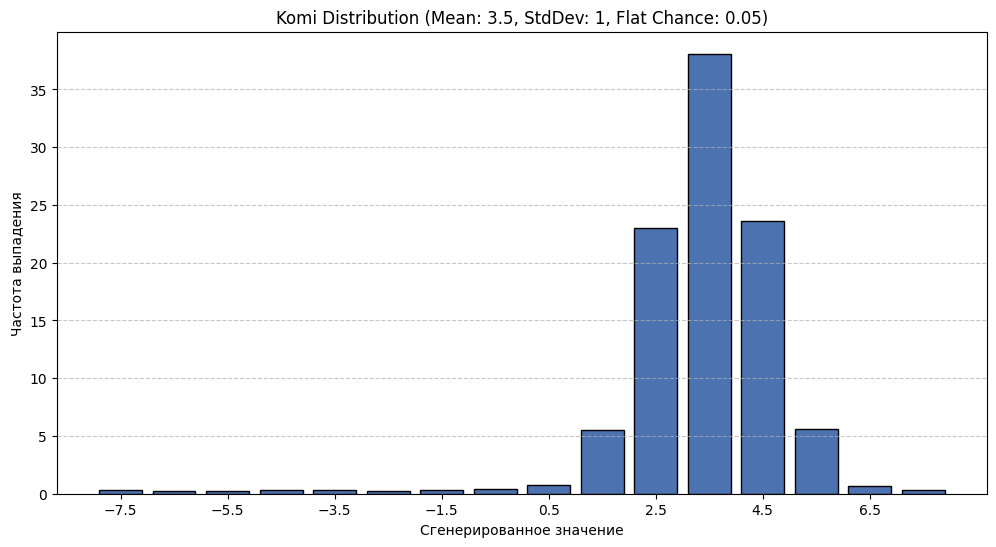

In [31]:
test_komi_generation(mean_komi=3.5, max_komi=8, std_dev=1, flat_chance=0.05)